In [1]:
import sys
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'

%load_ext autoreload
%autoreload 2



from jax import config

config.update("jax_enable_x64", True)

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"


import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import pickle
import optax
import jaxley as jx

import jax.random as jr
from typing import List


import equinox as eqx
import flax.nnx as nnx

from voltage_fitting.channels import NaTs2T, SKE2



Let's see the data!

In [2]:
t_max = 90.0
cut = 1500  # We cut the first 1500 datapoints because this period contains no stimulus

setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"



# Define target
from voltage_fitting.build_simulator import (
    get_experimental_data
)

t, v_data, i_amp = get_experimental_data(setup, cut, t_max)
v_data = jnp.asarray(v_data[None,])

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907


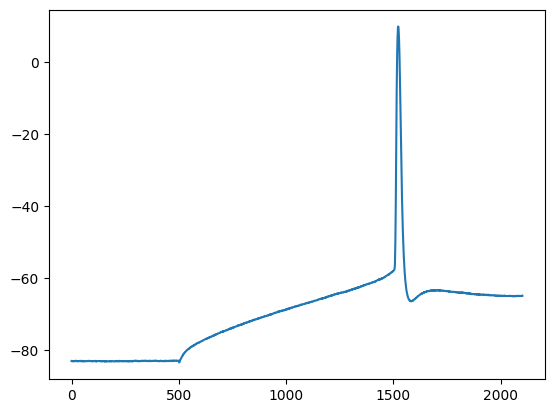

In [3]:
plt.plot(v_data[0])

Using only Leak(), NaTs2T(), SKE2() channels

In [4]:
# Define the single-compartment cell to train
from voltage_fitting.single_build_simulator import (
    setup_simulator,
    setup_simulator_step,
    build_cell,
    set_setup,
    get_bounds,
    transform_uniform_to_normal,
    get_prior
)

from voltage_fitting.loss_util import (
    get_scaled_loss,
)

seed = 2

rng_key = jax.random.PRNGKey(seed)

all_setup = set_setup(setup)
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"], include_H=False, include_M=False, include_Ca=False, include_SKv=False)
simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)


# Sampling parameters
_, lower, upper = get_bounds()

transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

v_single = simulate_single(inv_sampled_params, v_data[0], include_H=False, include_M=False, include_Ca=False, include_SKv=False)[0]


Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Number of parameters: 15


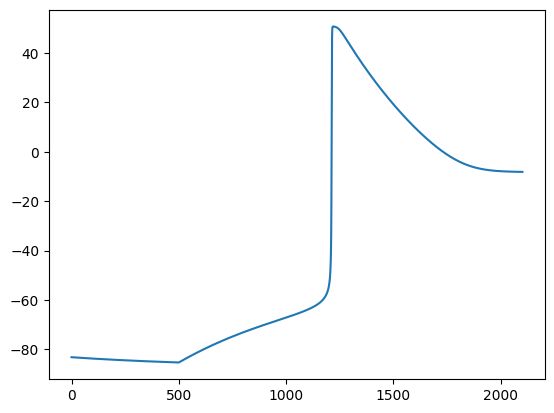

In [5]:
plt.plot(v_single[0])

**Initialization of the NNs**

In [6]:
from voltage_fitting.initialization import (
    rejection_sample_eigenvalues,
    sample_eigenvalues_on_circle,
    generate_all_lambda_matrices,
    generate_all_pi_matrices,
    generate_W_matrices,
)

key = jax.random.PRNGKey(0)
dt = 0.025
u_dimension = 8

eigs = rejection_sample_eigenvalues(
    solver_order=1,   
    h=dt,
    u_dim=u_dimension,
    use_complex=True,
    seed=0
)

print("Sampled Eigenvalues:")
for e in eigs:
    print(e, ", scaled with dt: ", dt*e)

Sampled Eigenvalues:
(-50.0794483756893+10.771963919255247j) , scaled with dt:  (-1.2519862093922327+0.2692990979813812j)
(-50.0794483756893-10.771963919255247j) , scaled with dt:  (-1.2519862093922327-0.2692990979813812j)
(-28.15989558241091+6.934780740697075j) , scaled with dt:  (-0.7039973895602728+0.17336951851742688j)
(-28.15989558241091-6.934780740697075j) , scaled with dt:  (-0.7039973895602728-0.17336951851742688j)
(-59.465594676991685-20.48113440227434j) , scaled with dt:  (-1.4866398669247922-0.5120283600568585j)
(-59.465594676991685+20.48113440227434j) , scaled with dt:  (-1.4866398669247922+0.5120283600568585j)
(-67.08656146288037+16.424147728475642j) , scaled with dt:  (-1.6771640365720093+0.41060369321189105j)
(-67.08656146288037-16.424147728475642j) , scaled with dt:  (-1.6771640365720093-0.41060369321189105j)


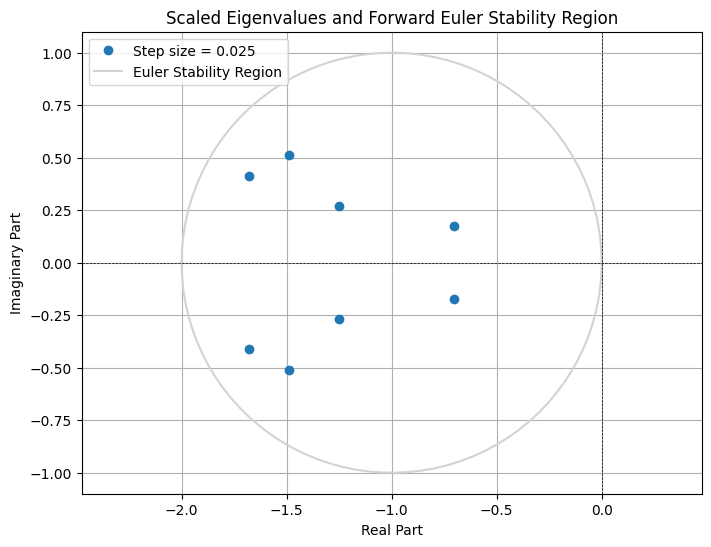

In [7]:
# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Plot scaled eigenvalues for each h
scaled_eigs = dt*eigs
ax.plot(scaled_eigs.real, scaled_eigs.imag, 'o', label=f"Step size = {dt}")

# Plot Euler's method stability region: circle centered at -1 with radius 1
theta = np.linspace(-np.pi, np.pi, 100)
x = -1 + np.cos(theta)
y = np.sin(theta)
ax.plot(x, y, color='lightgrey', label='Euler Stability Region')

ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.2, 0.2)

ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title("Scaled Eigenvalues and Forward Euler Stability Region")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")
ax.legend()
ax.grid(True)
plt.axis('equal')
plt.show()

In [8]:
num_layers = 3
layer_shapes = [(u_dimension + 1, 32), (32, 16), (16, u_dimension)]

lambda_matrices = generate_all_lambda_matrices(layer_shapes, eigs, num_layers)

pi_matrices = generate_all_pi_matrices(key, layer_shapes)

W_matrices = generate_W_matrices(lambda_matrices, pi_matrices)

**Define the NNs**

In [9]:
# Possible normalization functions
@jax.jit
def normalize_voltage(v):
    # Normalize voltage between -1 and 1
    return 2 * (v - jnp.min(v_data)) / (jnp.max(v_data) - jnp.min(v_data)) - 1

@jax.jit
def softsign_transform(v):
    return v / (1 + jnp.abs(v))

@jax.jit
def tempered_tanh(v, scale=0.05):
    return jnp.tanh(scale * v)

In [10]:
class SimpleNeuralNet(eqx.Module):
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear
    linear3: eqx.nn.Linear

    def __init__(self, *, key, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2, k3, k_b1, k_b2, k_b3 = jr.split(key, 6)

        self.linear1 = eqx.nn.Linear(u_dimension + 1, 32, key=k1)
        self.linear2 = eqx.nn.Linear(32, 16, key=k2)
        self.linear3 = eqx.nn.Linear(16, u_dimension, key=k3)


        self.linear1 = eqx.tree_at(lambda l: l.weight, self.linear1, W_matrices[0])
        self.linear2 = eqx.tree_at(lambda l: l.weight, self.linear2, W_matrices[1])
        self.linear3 = eqx.tree_at(lambda l: l.weight, self.linear3, W_matrices[2])

        self.linear1 = eqx.tree_at(
            lambda l: l.bias, self.linear1,
            jr.uniform(k_b1, (32,), minval=-epsilon, maxval=epsilon)
        )
        self.linear2 = eqx.tree_at(
            lambda l: l.bias, self.linear2,
            jr.uniform(k_b2, (16,), minval=-epsilon, maxval=epsilon)
        )
        self.linear3 = eqx.tree_at(
            lambda l: l.bias, self.linear3,
            jr.uniform(k_b3, (u_dimension,), minval=-epsilon, maxval=epsilon)
        )

    def __call__(self, x):
        x = jax.nn.relu(self.linear1(x))
        x = jax.nn.relu(self.linear2(x))
        return self.linear3(x)


class ReadoutNet(eqx.Module):
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear

    def __init__(self, *, key, u_dimension=8):
        k1, k2 = jr.split(key, 2)
        self.linear1 = eqx.nn.Linear(u_dimension, 32, key=k1)
        self.linear2 = eqx.nn.Linear(32, 1, key=k2)

    def __call__(self, u):
        x = jax.nn.relu(self.linear1(u))
        return self.linear2(x)


class CorrectionModel(eqx.Module):
    neural_net: SimpleNeuralNet
    readout_net: ReadoutNet
    channel_params_normal: jax.Array

    def __init__(self, *, key, init_params, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2 = jr.split(key, 2)
        self.neural_net = SimpleNeuralNet(key=k1, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.readout_net = ReadoutNet(key=k2, u_dimension=u_dimension)
        self.channel_params_normal = init_params

    def __call__(self, u, v):
        u_new = self.neural_net(u, v)
        return self.readout_net(u_new)
    
class DoubleCorrectionModel(eqx.Module):
    spike_neural_net: eqx.Module
    spike_readout_net: eqx.Module
    nospike_neural_net: eqx.Module
    nospike_readout_net: eqx.Module
    channel_params_normal: jnp.ndarray

    def __init__(self, *, key, init_params, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2, k3, k4 = jr.split(key, 4)
        self.spike_neural_net = SimpleNeuralNet(key=k1, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.spike_readout_net = ReadoutNet(key=k2, u_dimension=u_dimension)
        self.nospike_neural_net = SimpleNeuralNet(key=k3, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.nospike_readout_net = ReadoutNet(key=k4, u_dimension=u_dimension)
        self.channel_params_normal = init_params

    def __call__(self, u, v):
        u_new = self.neural_net(u, v)
        return self.readout_net(u_new)


**Define the simulation and the loss**

In [11]:
dt = 0.025
dv_treshold = 0.5


def simulate_full_trace(spike_neural_net, spike_readout_net, nospike_neural_net, nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, x_o, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr = None):
    def cond_fn(carry):
        t, _, _, _, diff, _ = carry
        keep_running = t < len(time_vec)
    
        if thr is None:
            return keep_running
        else:
            return jnp.logical_and(keep_running, diff < thr)

    def body_fn(carry):
        t, state, u, recs_adds, diff, prev_voltage = carry

        voltage = state["v"].squeeze()
        voltage_normalized = normalize_voltage(voltage)
        #voltage_normalized = softsign_transform(voltage)
        #voltage_normalized = tempered_tanh(voltage)


        inputs = jnp.concatenate([u, jnp.expand_dims(voltage_normalized, 0)], axis=0)

        # Spike/Nospike?
        dv = jnp.abs(voltage - prev_voltage)
        use_spike_net = dv > dv_treshold #jnp.logical_or(dv > dv_treshold), voltage > -40.0)
        
        # Compute add_current using spike/nospike NNs
        neural_net_output = jax.lax.cond(use_spike_net, lambda: spike_neural_net(inputs), lambda: nospike_neural_net(inputs))
        u_time_constant = jax.lax.cond(use_spike_net, lambda: spike_u_time_constant, lambda: nospike_u_time_constant)
        u_new = u + dt*neural_net_output / u_time_constant

        readout_net_output = jax.lax.cond(use_spike_net, lambda: spike_readout_net(u_new), lambda: nospike_readout_net(u_new))
        add_current = readout_net_output.squeeze()
        



        total_current = current[t] + add_current * added_curr_std
        state, rec = step_fn(state, total_current)
        rec_voltage = rec[0]



      
        new_us, new_recs, new_adds, nn_reses = recs_adds
        new_recs = new_recs.at[t].set(rec_voltage)
        new_adds = new_adds.at[t].set(add_current)
        new_us = new_us.at[t].set(u_new)
        nn_reses = nn_reses.at[t].set(neural_net_output)

        new_diff = diff + (rec_voltage - x_o[t + 1])**2

        return (t + 1, state, u_new.squeeze(), (new_us, new_recs, new_adds, nn_reses), new_diff, voltage)


    # Initialize buffers
    recs = jnp.full((len(time_vec),), jnp.nan)
    adds = jnp.full((len(time_vec),), jnp.nan)
    us = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)
    nn_reses = jnp.full((len(time_vec), u_init.shape[0]), jnp.nan)

    carry = (0, initial_state, u_init.squeeze(), (us, recs, adds, nn_reses), 0.0, initial_state["v"][0].squeeze())

    final_carry = eqx.internal.while_loop(
        cond_fun=cond_fn,
        body_fun=body_fn,
        init_val=carry,
        max_steps=len(time_vec),
        kind="bounded"
    )

    _, _, _, (us, recs, adds, nn_reses), _, _ = final_carry

    return recs, adds, us, nn_reses

In [12]:
cost_fn_power = 1.0
scale = 0.05

def loss_fn(model, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr=300, dtw_reg = 1.0, spike_reg = 0.0, mse_reg = 0.0, add_reg = 0.0):

    params = inv_transform_params(model.channel_params_normal)

    # Rebuild the simulator with new cell
    initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = params, include_H=False, include_M=False, include_Ca=False, include_SKv=False)

    # Run simulation
    preds, additional_currents, _, _ = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
    )

    preds = preds.squeeze()
    v_data = v_data.squeeze()

    mse_loss = jnp.sum(jnp.nan_to_num((preds - v_data) ** 2, nan=0.0))
    add_loss = jnp.sum(jnp.abs(jnp.nan_to_num(additional_currents, nan=0.0)))
    dtw_loss = get_scaled_loss(v_data, preds, cost_fn_power, scale)
    spike_loss = jnp.abs(jnp.max(preds) - jnp.max(v_data))
    
    return dtw_loss * dtw_reg + mse_loss * mse_reg + spike_loss * spike_reg + add_loss * add_reg

**How do they look like at initialization?**

In [13]:
# Simulate 3000 times with random parameters

from voltage_fitting.posthoc_summary_stats import (
    find_spikes,
    spike_count,
    first_spike_time,
    second_spike_time,
    spike_times,
    first_spike_amp,
    second_spike_amp,
)

cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"], include_H=False, include_M=False, include_Ca=False, include_SKv=False)

n_params = 3_000
opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, n_params)
)

def predict(params):
    inv_params = inv_transform_params(params)
    simulate_single = setup_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)
    v = simulate_single(inv_params, v_data[0], include_H=False, include_M=False, include_Ca=False, include_SKv=False)[0][0]
    return v

vmapped_predict = jax.vmap(predict)
x_preds = vmapped_predict(opt_params)

_ = np.random.seed(0)
noise = np.random.randn(len(v_data[0])) * 1e-2

if setup == "473601979":
    thr = -30.0
else:
    thr = -20.0  # Default value.

v_data_spikes = find_spikes(v_data[0] + noise, None, None, thr)
v_data_ss = {
    "spike_count": spike_count(v_data_spikes),
    "first_spike_time": first_spike_time(v_data_spikes),
    "second_spike_time": second_spike_time(v_data_spikes),
    "first_spike_amp": first_spike_amp(v_data[0], v_data_spikes),
    "second_spike_amp": second_spike_amp(v_data[0], v_data_spikes),
}

pred_spikes = jax.vmap(find_spikes, in_axes=(0, None, None, None))(
    x_preds, None, None, thr
)
pred_ss = {
    "spike_count": np.asarray([spike_count(p) for p in pred_spikes]),
    "first_spike_time": np.asarray([first_spike_time(p) for p in pred_spikes]),
    "second_spike_time": np.asarray([second_spike_time(p) for p in pred_spikes]),
    "first_spike_amp": np.asarray(
        [first_spike_amp(xp, p) for xp, p in zip(x_preds, pred_spikes)]
    ),
    "second_spike_amp": np.asarray(
        [second_spike_amp(xp, p) for xp, p in zip(x_preds, pred_spikes)]
    ),
}

errors = {}
for key in v_data_ss.keys():
    errors[key] = np.abs(v_data_ss[key] - pred_ss[key])

# Weigh the individusal errors.
summed_errors = (
    np.asarray(errors["spike_count"]).astype(float) * 5.0
    + np.asarray(errors["first_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["second_spike_time"]).astype(float) * 2.0
    + np.asarray(errors["first_spike_amp"]).astype(float) * 1.0
    + np.asarray(errors["second_spike_amp"]).astype(float) * 1.0
)

vmapped_scaled_dtw_loss = jax.vmap(get_scaled_loss, in_axes=(None, 0, None, None, None))
scaled_dtw_errors = vmapped_scaled_dtw_loss(v_data[0], x_preds, 1.0, 0.05, 1.0)#, cost_fn_power=1.0, scale=0.05, penalty_rate=1.0)

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


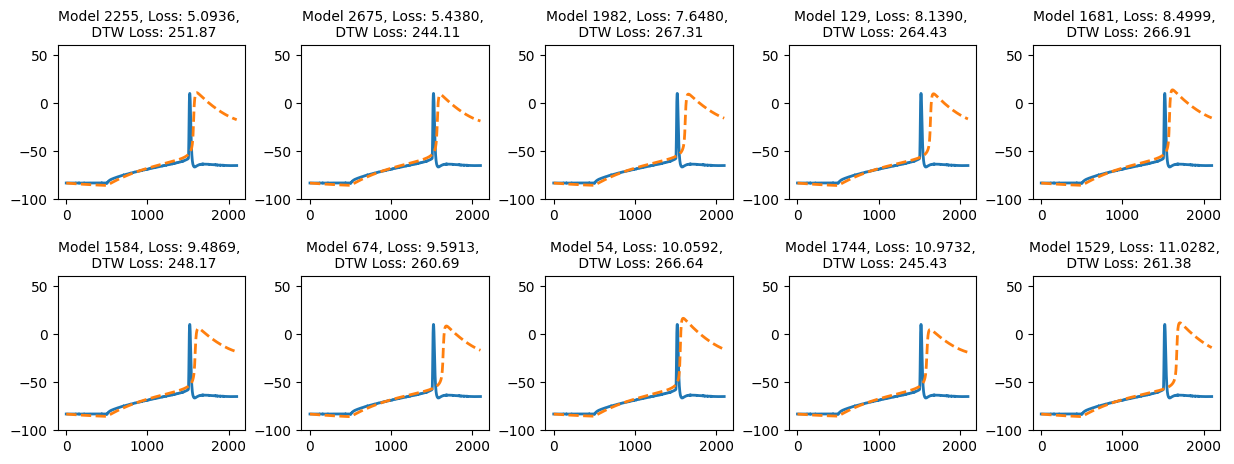

In [14]:
# 10 best results based on summed errors
inds = np.argsort(summed_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(x_preds[inds[i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

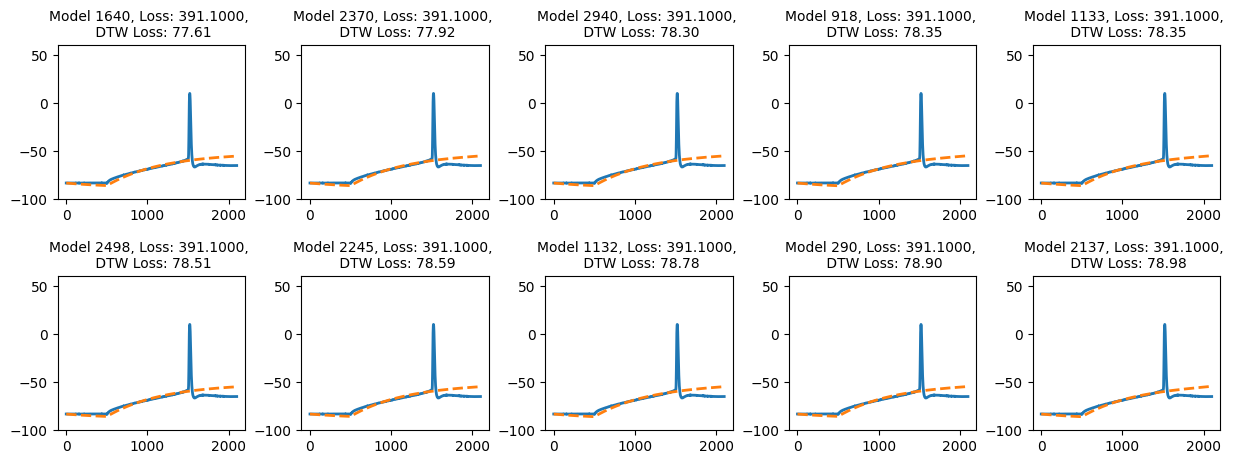

In [15]:
# 10 best results based on dtw loss
inds = np.argsort(scaled_dtw_errors)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        axs[i,j].plot(v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(x_preds[inds[0 + i*5+j]], label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {summed_errors[inds[i*5+j]]:.4f}, \n DTW Loss: {scaled_dtw_errors[inds[i*5+j]]:.2f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

**Initialize and train**

In [16]:
u_dimension = 8
np.random.seed(42)
n_particles = 300

key1 = jax.random.PRNGKey(0)
key2 = jax.random.PRNGKey(1)
keys = jax.random.split(jax.random.PRNGKey(0), num=n_particles)

u_init = jnp.asarray(np.random.randn(u_dimension))  # Initial hidden state of the neural network
epsilon = 1e-4

all_setup = set_setup(setup)

# Different, random u_time_constant vectors
log_uniform_samples = jax.random.uniform(key1, shape=(u_dimension,), minval=np.log(1), maxval=np.log(100.0))
nospike_u_time_constant = jnp.exp(log_uniform_samples)

log_uniform_samples = jax.random.uniform(key2, shape=(u_dimension,), minval=np.log(0.1), maxval=np.log(10.0))
spike_u_time_constant = jnp.exp(log_uniform_samples)

added_curr_std = 1.0/10.0


thr = None


# Setup for learning rate scheduler
initial_lr = 15e-4
decay_factor = 0.99 
transition_steps = 1  # decay after every epoch
decay_start = 100 # 600
decay_end = 250 # 350

# Initialize n_particles different parameter sets
opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, n_particles)
)


def initialize_model(key, init_params, u_dimension, W_matrices, epsilon):
    model = DoubleCorrectionModel(
        key=key,
        init_params=init_params,
        u_dimension=u_dimension,
        W_matrices=W_matrices,
        epsilon=epsilon
    )
    return model


models = jax.vmap(initialize_model, in_axes=(0, 0, None, None, None))(
    keys, opt_params, u_dimension, W_matrices, epsilon
)

# Scheduler
raw_schedule = optax.exponential_decay(
    init_value=initial_lr,
    transition_steps=transition_steps,
    decay_rate=decay_factor,
    staircase=True,
)

def custom_schedule(step):
    # Epochs before decay_start → constant
    lr = initial_lr

    # Epochs between decay_start and decay_end → decay
    decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
    lr = jnp.where(
        step < decay_start,
        initial_lr,
        raw_schedule(decay_steps)
    )

    # After decay_end → freeze at last decayed value
    final_lr = raw_schedule(decay_end - decay_start)
    lr = jnp.where(step > decay_end, final_lr, lr)

    return lr

# Possible optimizers
adam_optimizer = optax.adam(learning_rate=custom_schedule)
lbfgs_optimizer = optax.chain(optax.scale_by_lbfgs(memory_size = 6), optax.scale(-1e-3))
adamw_optimizer = optax.adamw(learning_rate=custom_schedule, weight_decay=1e-4)

def init_adam_optimizer_state(model):
    return adam_optimizer.init(eqx.filter(model, eqx.is_inexact_array))

def init_lbfgs_optimizer_state(model):
    return lbfgs_optimizer.init(eqx.filter(model, eqx.is_inexact_array)) 

def init_adamw_optimizer_state(model):
    return adamw_optimizer.init(eqx.filter(model, eqx.is_inexact_array))


optimizer_states = jax.vmap(init_adam_optimizer_state)(models)
# optimizer_states = jax.vmap(init_adamw_optimizer_state)(models)
# optimizer_states = jax.vmap(init_lbfgs_optimizer_state)(models)


# Loss for optimization and fine-tuning
def simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr, dtw_reg = 1.0, spike_reg = 2.0, mse_reg = 0.0, add_reg = 0.0)
        return loss

def fine_simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr, dtw_reg = 0.0, spike_reg = 0.0, mse_reg = 1.0, add_reg = 0.0)
        return loss


grad_fn = nnx.jit(jax.vmap(nnx.value_and_grad(simulation_loss_fn)))
fine_grad_fn = nnx.jit(jax.vmap(nnx.value_and_grad(fine_simulation_loss_fn)))


# Set up the cell
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], include_H=False, include_M=False, include_Ca=False, include_SKv=False)

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current, verbose = False)
cell.record(verbose = False)
cell.set("v", all_setup['v_init'])
cell.init_states()

In [17]:
num_epochs = 300
mean_losses = []

# Storing the best models and their losses during training
best_losses = jnp.full((1,), jnp.inf)
best_models = models  # Start with the initial models as best
grads_list = []
model_snapshots = []

# Normalizing, scaling or clipping gradients
def clip_gradients(grads, max_norm=10.0, eps=1e-8):
    def clip_leaf(grad):
        flat = grad.reshape((grad.shape[0], -1)) if grad.ndim > 1 else grad[:, None]
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling
    return jax.tree_util.tree_map(clip_leaf, grads)

def clip_channel_gradients(grads, max_norm=10.0, eps=1e-8):
    def clip_leaf(grad):
        flat = grad.reshape((grad.shape[0], -1)) if grad.ndim > 1 else grad[:, None]
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling

    clipped = clip_leaf(grads.channel_params_normal)
    grads = eqx.tree_at(lambda g: g.channel_params_normal, grads, clipped)
    return grads

def clip_network_gradients(grads, max_norm=1.0, eps=1e-8):
    def clip_leaf(grad):
        if grad.ndim < 2:
            return grad  # Skip biases or scalars
        flat = grad.reshape((grad.shape[0], -1))
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling

    def clip_net(net_grads):
        return jax.tree_util.tree_map(clip_leaf, net_grads)

    grads = eqx.tree_at(lambda g: g.spike_neural_net, grads, clip_net(grads.spike_neural_net))
    grads = eqx.tree_at(lambda g: g.spike_readout_net, grads, clip_net(grads.spike_readout_net))
    grads = eqx.tree_at(lambda g: g.nospike_neural_net, grads, clip_net(grads.nospike_neural_net))
    grads = eqx.tree_at(lambda g: g.nospike_readout_net, grads, clip_net(grads.nospike_readout_net))

    return grads

def normalize_gradients(grads, beta=1.0, eps=1e-8):
    def normalize_leaf(grad):
        norm = jnp.linalg.norm(grad, axis=1, keepdims=True)
        return grad / (norm ** beta + eps)

    grads = jax.tree_util.tree_map(normalize_leaf, grads)
    return grads

def normalize_channel_gradients(grads, beta=1.0, eps=1e-8):
    norms = jnp.linalg.norm(grads.channel_params_normal, axis=1, keepdims=True)
    normalized = grads.channel_params_normal / (norms ** beta + eps)

    # Replace only the channel_params_normal field
    grads = eqx.tree_at(lambda g: g.channel_params_normal, grads, normalized)
    return grads

def scale_grads(grads, lr_spike, lr_nospike, lr_channel):
    def scale_tree(tree, factor):
        return jax.tree_util.tree_map(lambda x: x * factor, tree)

    grads_scaled = grads

    grads_scaled = eqx.tree_at(lambda g: g.spike_neural_net, grads_scaled,
                            scale_tree(grads.spike_neural_net, lr_spike))
    grads_scaled = eqx.tree_at(lambda g: g.spike_readout_net, grads_scaled,
                            scale_tree(grads.spike_readout_net, lr_spike))
    grads_scaled = eqx.tree_at(lambda g: g.nospike_neural_net, grads_scaled,
                            scale_tree(grads.nospike_neural_net, lr_nospike))
    grads_scaled = eqx.tree_at(lambda g: g.nospike_readout_net, grads_scaled,
                            scale_tree(grads.nospike_readout_net, lr_nospike))
    grads_scaled = eqx.tree_at(lambda g: g.channel_params_normal, grads_scaled,
                            grads.channel_params_normal * lr_channel)

    return grads_scaled

for epoch in range(num_epochs):

    loss, grads = grad_fn(models)
    grads_list.append(grads)
        
    
    grads = clip_channel_gradients(grads, max_norm=10.0, eps=1e-8)
    #grads = scale_grads(grads, lr_spike=10, lr_nospike = 1e-2, lr_channel=1.0)
    grads = clip_network_gradients(grads, max_norm=10.0, eps=1e-8)



    improved = loss < best_losses
    best_losses = jnp.where(improved, loss, best_losses)

    def replace_if_improved(new, old):
        mask = improved.reshape((-1,) + (1,) * (new.ndim - 1))
        return jnp.where(mask, new, old)

    best_models = jax.tree_util.tree_map(replace_if_improved, models, best_models)

    mask = ~jnp.isnan(loss)
    mean_loss = jnp.sum(loss[mask]) / jnp.sum(mask)
    mean_losses.append(mean_loss)

    updates, optimizer_states = jax.vmap(lambda g, s, m: adam_optimizer.update(g, s, m, step = epoch))(grads, optimizer_states, models)
    models = jax.vmap(eqx.apply_updates)(models, updates)
    model_snapshots.append(jax.tree_util.tree_map(lambda x: x.copy(), models))

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Mean Loss: {mean_loss:.6f}, Median Loss {jnp.median(loss[mask]):.6f}, Min Loss: {jnp.min(loss[mask]):.6f}")

        print(jnp.max(jnp.linalg.norm(grads.channel_params_normal, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear3.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear3.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear3.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear3.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear2.bias, axis=1)))

/Users/moldor/anaconda3/envs/jaxley_env/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


Epoch 0, Mean Loss: 603.118614, Median Loss 416.031101, Min Loss: 157.674036
9.999999999996591 7.231010249604362 9.99999999984342 8.471023083549946 9.999999999946926 9.235259987921992 9.999999999967834 5.379089902922031 9.99999999994816 9.999999999996417 9.999999999977764 7.496852317790407 9.999999999963952 9.301076166942597 9.999999999971322 7.681839138364989 9.999999999990159 7.860798129453172 9.999999999988399 9.999999999998339 9.99999999999545
Epoch 10, Mean Loss: 476.081948, Median Loss 414.537449, Min Loss: 105.749476
9.999999999996906 7.428231921392802 9.999999999610127 8.250963708019265 9.999999999723228 8.645684379585788 9.999999999933033 4.962227979223038 9.9999999995225 9.999999999941618 9.999999999831019 7.728996189304567 9.999999999977533 9.450913316741225 9.999999999987905 8.818425761768001 9.999999999995888 8.022753355303717 9.999999999994523 9.999999999998911 9.999999999997938
Epoch 20, Mean Loss: 406.032687, Median Loss 411.125522, Min Loss: 102.299320
9.99999999999898

In [101]:
nan_mask = jnp.isnan(grads_list[num_epochs-1].channel_params_normal)

# Get indices where the mask is True
nan_indices = jnp.argwhere(nan_mask)
print("Not successfully trained models:", int(len(nan_indices)/15))

Not successfully trained models: 0


**With the NNs**

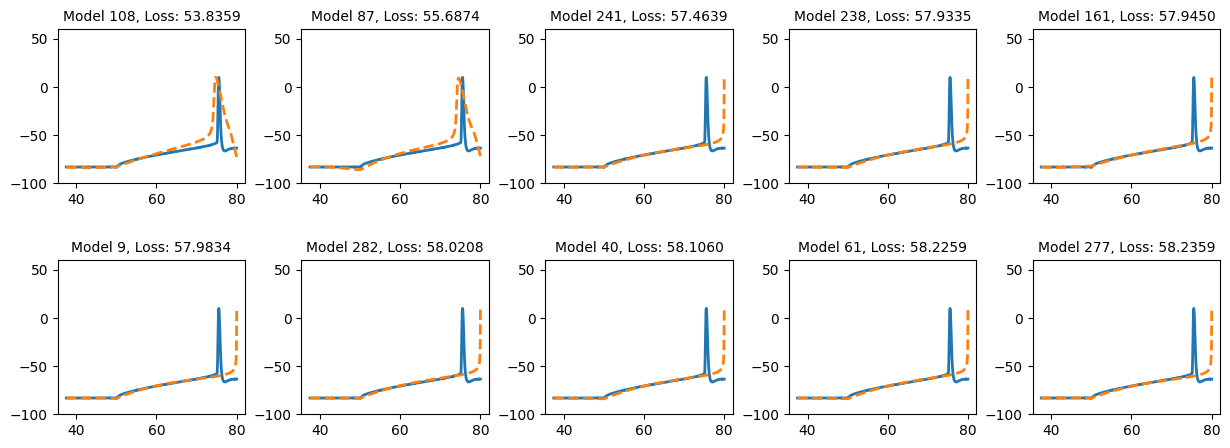

In [43]:
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'],  include_H=False, include_M=False, include_Ca=False, include_SKv=False)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params,  include_H=False, include_M=False, include_Ca=False, include_SKv=False)

        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

**Without the NNs**

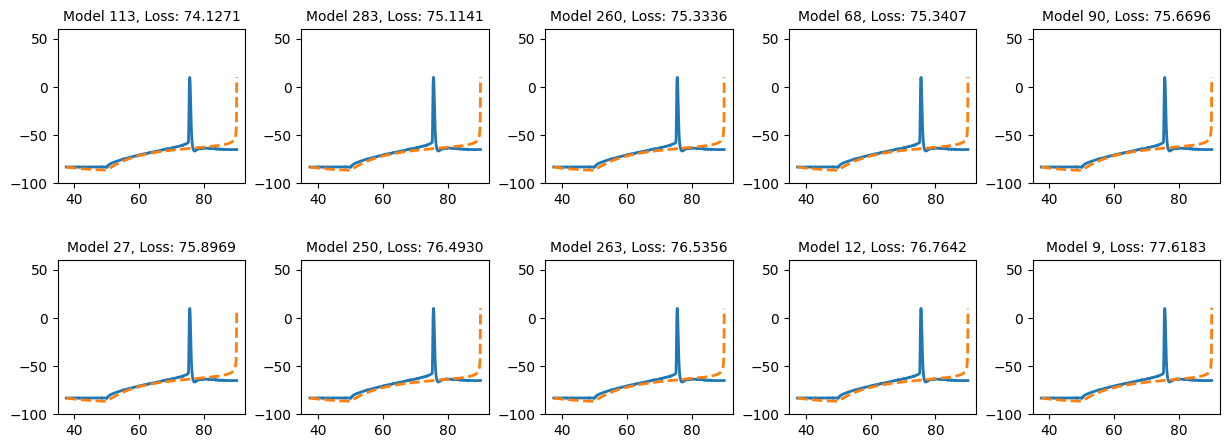

In [102]:
#longer
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'],  include_H=False, include_M=False, include_Ca=False, include_SKv=False)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params,  include_H=False, include_M=False, include_Ca=False, include_SKv=False)

        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

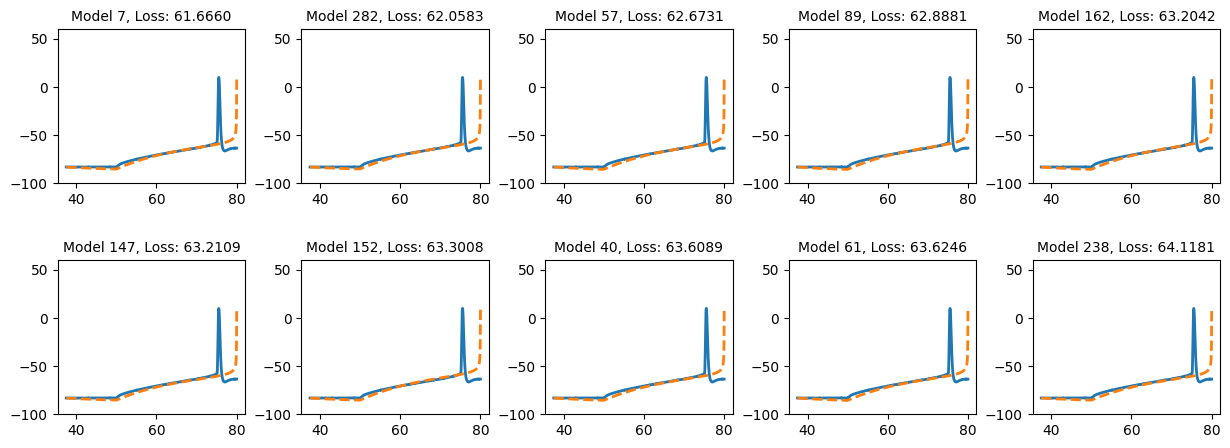

In [37]:
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'],  include_H=False, include_M=False, include_Ca=False, include_SKv=False)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params,  include_H=False, include_M=False, include_Ca=False, include_SKv=False)

        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

**Adding interpolation to the m_gates and h_gates in the NaTs2T and SKE2 channels**

In [79]:
class SimpleNeuralNet(eqx.Module):
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear
    linear3: eqx.nn.Linear

    def __init__(self, *, key, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2, k3, k_b1, k_b2, k_b3 = jr.split(key, 6)

        self.linear1 = eqx.nn.Linear(u_dimension + 1, 32, key=k1)
        self.linear2 = eqx.nn.Linear(32, 16, key=k2)
        self.linear3 = eqx.nn.Linear(16, u_dimension, key=k3)


        self.linear1 = eqx.tree_at(lambda l: l.weight, self.linear1, W_matrices[0])
        self.linear2 = eqx.tree_at(lambda l: l.weight, self.linear2, W_matrices[1])
        self.linear3 = eqx.tree_at(lambda l: l.weight, self.linear3, W_matrices[2])

        self.linear1 = eqx.tree_at(
            lambda l: l.bias, self.linear1,
            jr.uniform(k_b1, (32,), minval=-epsilon, maxval=epsilon)
        )
        self.linear2 = eqx.tree_at(
            lambda l: l.bias, self.linear2,
            jr.uniform(k_b2, (16,), minval=-epsilon, maxval=epsilon)
        )
        self.linear3 = eqx.tree_at(
            lambda l: l.bias, self.linear3,
            jr.uniform(k_b3, (u_dimension,), minval=-epsilon, maxval=epsilon)
        )

    def __call__(self, x):
        x = jax.nn.relu(self.linear1(x))
        x = jax.nn.relu(self.linear2(x))
        return self.linear3(x)


class ReadoutNet(eqx.Module):
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear

    def __init__(self, *, key, u_dimension=8):
        k1, k2 = jr.split(key, 2)
        self.linear1 = eqx.nn.Linear(u_dimension, 32, key=k1)
        self.linear2 = eqx.nn.Linear(32, 1, key=k2)

    def __call__(self, u):
        x = jax.nn.relu(self.linear1(u))
        return self.linear2(x)


class CorrectionModel(eqx.Module):
    neural_net: SimpleNeuralNet
    readout_net: ReadoutNet
    channel_params_normal: jax.Array

    def __init__(self, *, key, init_params, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2 = jr.split(key, 2)
        self.neural_net = SimpleNeuralNet(key=k1, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.readout_net = ReadoutNet(key=k2, u_dimension=u_dimension)
        self.channel_params_normal = init_params

    def __call__(self, u, v):
        u_new = self.neural_net(u, v)
        return self.readout_net(u_new)
    
class DoubleCorrectionModel(eqx.Module):
    spike_neural_net: eqx.Module
    spike_readout_net: eqx.Module
    nospike_neural_net: eqx.Module
    nospike_readout_net: eqx.Module
    channel_params_normal: jnp.ndarray
    NaTs2T_gating_params: jnp.ndarray
    SKE2_gating_params: jnp.ndarray


    def __init__(self, *, key, init_params, init_NaTs2T_gating_params, init_SKE2_gating_params, u_dimension=8, W_matrices: List[jax.Array], epsilon: float = 1e-4):
        k1, k2, k3, k4 = jr.split(key, 4)
        self.spike_neural_net = SimpleNeuralNet(key=k1, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.spike_readout_net = ReadoutNet(key=k2, u_dimension=u_dimension)
        self.nospike_neural_net = SimpleNeuralNet(key=k3, u_dimension=u_dimension, W_matrices=W_matrices, epsilon=epsilon)
        self.nospike_readout_net = ReadoutNet(key=k4, u_dimension=u_dimension)
        self.channel_params_normal = init_params
        self.NaTs2T_gating_params = init_NaTs2T_gating_params
        self.SKE2_gating_params = init_SKE2_gating_params

    def __call__(self, u, v):
        u_new = self.neural_net(u, v)
        return self.readout_net(u_new)


In [80]:
cost_fn_power = 1.0
scale = 0.05

def loss_fn(model, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr=300, dtw_reg = 1.0, spike_reg = 2.0, mse_reg = 0.0, add_reg = 0.0):

    params = inv_transform_params(model.channel_params_normal)

    Na_dict = NaTs2T(gating_params=model.NaTs2T_gating_params).init_state(0, all_setup["v_init"], cell.channels[1].channel_params, dt)
    Na_m = Na_dict['NaTs2T_m']
    Na_h = Na_dict['NaTs2T_h']

    Sk_dict = SKE2(gating_params=model.SKE2_gating_params).init_state(0, all_setup['v_init'], cell.channels[2].channel_params, dt)
    Sk_z = Sk_dict['SKE2_z']

    # Rebuild the simulator with new cell
    initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = params, Na_m = Na_m, Na_h = Na_h, Sk_z = None, include_H=False, include_M=False, include_Ca=False, include_SKv=False)

    # Run simulation
    preds, additional_currents, _, _ = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
    )

    preds = preds.squeeze()
    v_data = v_data.squeeze()

    mse_loss = jnp.sum(jnp.nan_to_num((preds - v_data) ** 2, nan=0.0))
    add_loss = jnp.sum(jnp.abs(jnp.nan_to_num(additional_currents, nan=0.0)))
    dtw_loss = get_scaled_loss(v_data, preds, cost_fn_power, scale)
    spike_loss = jnp.abs(jnp.max(preds) - jnp.max(v_data))
    
    return dtw_loss * dtw_reg + mse_loss * mse_reg + spike_loss * spike_reg + add_loss * add_reg

In [81]:
u_dimension = 8
np.random.seed(42)
n_particles = 300

master_key = jax.random.PRNGKey(0)
key1, key2, key3, key4 = jax.random.split(master_key, num = 4)
keys = jax.random.split(master_key, num=n_particles)

u_init = jnp.asarray(np.random.randn(u_dimension))  # Initial hidden state of the neural network
epsilon = 1e-4

all_setup = set_setup(setup)

# Different, random u_time_constant vectors
log_uniform_samples = jax.random.uniform(key1, shape=(u_dimension,), minval=np.log(1), maxval=np.log(100.0))
nospike_u_time_constant = jnp.exp(log_uniform_samples)

log_uniform_samples = jax.random.uniform(key2, shape=(u_dimension,), minval=np.log(0.1), maxval=np.log(10.0))
spike_u_time_constant = jnp.exp(log_uniform_samples)

added_curr_std = 1.0/10.0


thr = None


# Setup for learning rate scheduler
initial_lr = 15e-4
decay_factor = 0.99 
transition_steps = 1  # decay after every epoch
decay_start = 100 # 600
decay_end = 250 # 350

# Initialize n_particles different parameter sets
opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, n_particles)
)
init_NaTs2T_gating_params = jax.random.normal(key3, shape=(n_particles, 40))
init_SKE2_gating_params = jax.random.normal(key4, shape=(n_particles, 10))

def initialize_model(key, init_params, Na_gating_params, SKE2_gating_params, u_dimension, W_matrices, epsilon):
    model = DoubleCorrectionModel(
        key=key,
        init_params=init_params,
        init_NaTs2T_gating_params=Na_gating_params,
        init_SKE2_gating_params=SKE2_gating_params,
        u_dimension=u_dimension,
        W_matrices=W_matrices,
        epsilon=epsilon
    )
    return model


models = jax.vmap(initialize_model, in_axes=(0, 0, 0, 0, None, None, None))(
    keys, opt_params, init_NaTs2T_gating_params, init_SKE2_gating_params, u_dimension, W_matrices, epsilon
)

# Scheduler
raw_schedule = optax.exponential_decay(
    init_value=initial_lr,
    transition_steps=transition_steps,
    decay_rate=decay_factor,
    staircase=True,
)

def custom_schedule(step):
    # Epochs before decay_start → constant
    lr = initial_lr

    # Epochs between decay_start and decay_end → decay
    decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
    lr = jnp.where(
        step < decay_start,
        initial_lr,
        raw_schedule(decay_steps)
    )

    # After decay_end → freeze at last decayed value
    final_lr = raw_schedule(decay_end - decay_start)
    lr = jnp.where(step > decay_end, final_lr, lr)

    return lr

# Possible optimizers
adam_optimizer = optax.adam(learning_rate=custom_schedule)
lbfgs_optimizer = optax.chain(optax.scale_by_lbfgs(memory_size = 6), optax.scale(-1e-3))
adamw_optimizer = optax.adamw(learning_rate=custom_schedule, weight_decay=1e-4)

def init_adam_optimizer_state(model):
    return adam_optimizer.init(eqx.filter(model, eqx.is_inexact_array))

def init_lbfgs_optimizer_state(model):
    return lbfgs_optimizer.init(eqx.filter(model, eqx.is_inexact_array)) 

def init_adamw_optimizer_state(model):
    return adamw_optimizer.init(eqx.filter(model, eqx.is_inexact_array))


optimizer_states = jax.vmap(init_adam_optimizer_state)(models)
# optimizer_states = jax.vmap(init_adamw_optimizer_state)(models)
# optimizer_states = jax.vmap(init_lbfgs_optimizer_state)(models)


# Loss for optimization and fine-tuning
def simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr, dtw_reg = 1.0, spike_reg = 2.0, mse_reg = 0.0, add_reg = 0.0)
        return loss

def fine_simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, u_init, v_data, added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr, dtw_reg = 0.0, spike_reg = 0.0, mse_reg = 1.0, add_reg = 0.0)
        return loss


grad_fn = nnx.jit(jax.vmap(nnx.value_and_grad(simulation_loss_fn)))
fine_grad_fn = nnx.jit(jax.vmap(nnx.value_and_grad(fine_simulation_loss_fn)))


# Set up the cell
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], include_H=False, include_M=False, include_Ca=False, include_SKv=False)

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current, verbose = False)
cell.record(verbose = False)
cell.set("v", all_setup['v_init'])
cell.init_states()

In [83]:
num_epochs = 300
mean_losses = []

# Storing the best models and their losses during training
best_gate_losses = jnp.full((1,), jnp.inf)
best_gate_models = models  # Start with the initial models as best
grads_list = []
model_snapshots = []

def clip_gating_gradients(grads, max_norm=10.0, eps=1e-8):
    def clip_leaf(grad):
        flat = grad.reshape((grad.shape[0], -1)) if grad.ndim > 1 else grad[:, None]
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling

    clipped_Na = clip_leaf(grads.NaTs2T_gating_params)
    clipped_K = clip_leaf(grads.SKE2_gating_params)
    grads = eqx.tree_at(lambda g: g.NaTs2T_gating_params, grads, clipped_Na)
    grads = eqx.tree_at(lambda g: g.SKE2_gating_params, grads, clipped_K)
    return grads


for epoch in range(num_epochs):

    loss, grads = grad_fn(models)
    grads_list.append(grads)
        
    
    grads = clip_channel_gradients(grads, max_norm=10.0, eps=1e-8)
    #grads = clip_gating_gradients(grads, max_norm=10.0, eps=1e-8)
    #grads = scale_grads(grads, lr_spike=10, lr_nospike = 1e-2, lr_channel=1.0)
    grads = clip_network_gradients(grads, max_norm=10.0, eps=1e-8)



    improved = loss < best_gate_losses
    best_gate_losses = jnp.where(improved, loss, best_gate_losses)

    def replace_if_improved(new, old):
        mask = improved.reshape((-1,) + (1,) * (new.ndim - 1))
        return jnp.where(mask, new, old)

    best_gate_models = jax.tree_util.tree_map(replace_if_improved, models, best_gate_models)

    mask = ~jnp.isnan(loss)
    mean_loss = jnp.sum(loss[mask]) / jnp.sum(mask)
    mean_losses.append(mean_loss)

    updates, optimizer_states = jax.vmap(lambda g, s, m: adam_optimizer.update(g, s, m, step = epoch))(grads, optimizer_states, models)
    models = jax.vmap(eqx.apply_updates)(models, updates)
    model_snapshots.append(jax.tree_util.tree_map(lambda x: x.copy(), models))

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Mean Loss: {mean_loss:.6f}, Median Loss {jnp.median(loss[mask]):.6f}, Min Loss: {jnp.min(loss[mask]):.6f}")

        print(jnp.max(jnp.linalg.norm(grads.channel_params_normal, axis=1)), jnp.max(jnp.linalg.norm(grads.NaTs2T_gating_params, axis=1)), jnp.max(jnp.linalg.norm(grads.SKE2_gating_params, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear3.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_neural_net.linear3.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.spike_readout_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear2.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear3.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_neural_net.linear3.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear1.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear1.bias, axis=1)),
          jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear2.weight, axis=2)), jnp.max(jnp.linalg.norm(grads.nospike_readout_net.linear2.bias, axis=1)))

/Users/moldor/anaconda3/envs/jaxley_env/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


Epoch 0, Mean Loss: 394.158597, Median Loss 311.852407, Min Loss: 100.312110
9.999999999989525 38449.68290121632 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
Epoch 10, Mean Loss: 388.230800, Median Loss 310.313582, Min Loss: 84.679456
9.999999999996247 260.77081002595423 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
Epoch 20, Mean Loss: 384.688463, Median Loss 309.502551, Min Loss: 80.431008
9.999999999999238 195.868037247904 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
Epoch 30, Mean Loss: 381.646394, Median Loss 308.470406, Min Loss: 80.550986
9.999999999999178 146.0335661084629 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
Epoch 40, Mean Loss: 378.453956, Median Loss 307.516584, Min Loss: 81.099835
9.999999999999526 130.9060312530281 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
Epoch 50, Mean 

**With NaTs2T and SKE2 gating params, no NNs**

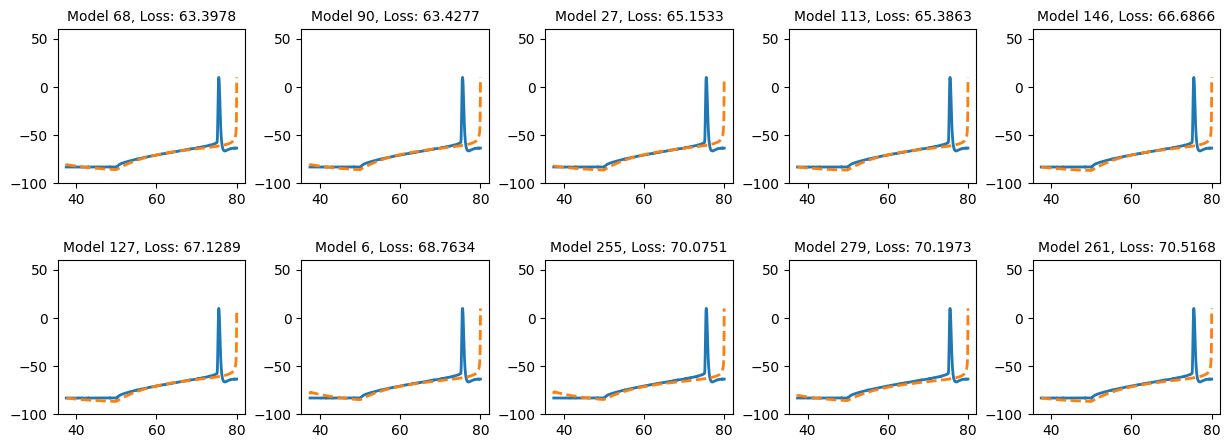

In [84]:
#only Na gating params
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'],  include_H=False, include_M=False, include_Ca=False, include_SKv=False)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        Na_dict = NaTs2T(gating_params=model.NaTs2T_gating_params).init_state(0, all_setup["v_init"], cell.channels[1].channel_params, dt)
        Na_m = Na_dict['NaTs2T_m']
        Na_h = Na_dict['NaTs2T_h']

        Sk_dict = SKE2(gating_params=model.SKE2_gating_params).init_state(0, all_setup['v_init'], cell.channels[2].channel_params, dt)
        Sk_z = Sk_dict['SKE2_z']

        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params, Na_m = Na_m, Na_h = Na_h, Sk_z = Sk_z, include_H=False, include_M=False, include_Ca=False, include_SKv=False)

        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

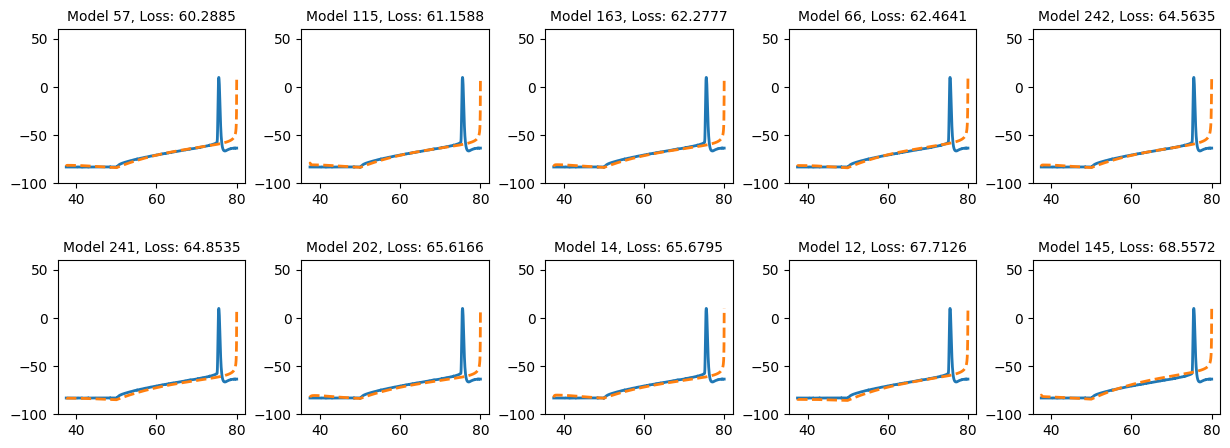

In [ ]:
#spike reg
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'],  include_H=False, include_M=False, include_Ca=False, include_SKv=False)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        Na_dict = NaTs2T(gating_params=model.NaTs2T_gating_params).init_state(0, all_setup["v_init"], cell.channels[1].channel_params, dt)
        Na_m = Na_dict['NaTs2T_m']
        Na_h = Na_dict['NaTs2T_h']

        Sk_dict = SKE2(gating_params=model.SKE2_gating_params).init_state(0, all_setup['v_init'], cell.channels[2].channel_params, dt)
        Sk_z = Sk_dict['SKE2_z']

        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params, Na_m = Na_m, Na_h = Na_h, Sk_z = Sk_z, include_H=False, include_M=False, include_Ca=False, include_SKv=False)

        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

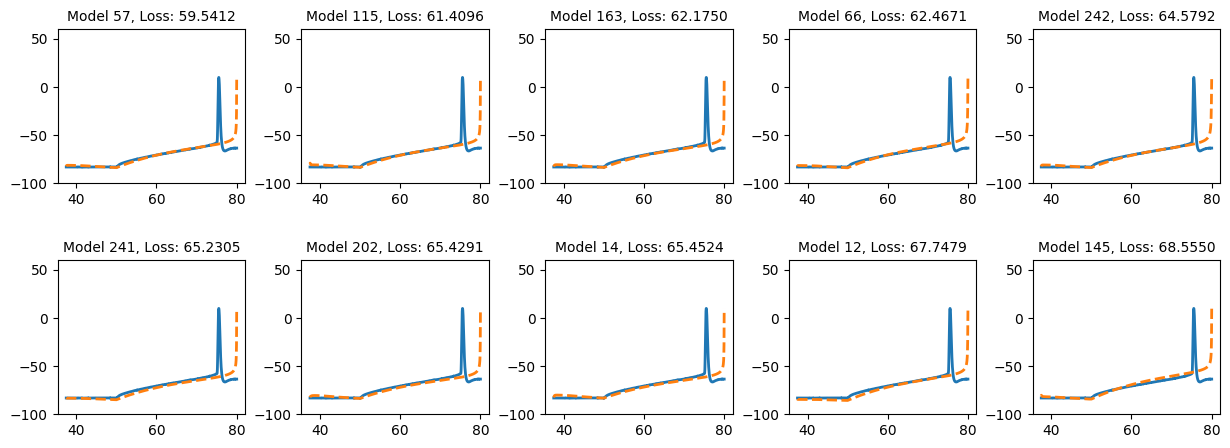

In [99]:
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'],  include_H=False, include_M=False, include_Ca=False, include_SKv=False)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        Na_dict = NaTs2T(gating_params=model.NaTs2T_gating_params).init_state(0, all_setup["v_init"], cell.channels[1].channel_params, dt)
        Na_m = Na_dict['NaTs2T_m']
        Na_h = Na_dict['NaTs2T_h']

        Sk_dict = SKE2(gating_params=model.SKE2_gating_params).init_state(0, all_setup['v_init'], cell.channels[2].channel_params, dt)
        Sk_z = Sk_dict['SKE2_z']

        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params, Na_m = Na_m, Na_h = Na_h, Sk_z = Sk_z, include_H=False, include_M=False, include_Ca=False, include_SKv=False)

        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

**With NaTs2T and SKE2 gating parameters, but with NNs**

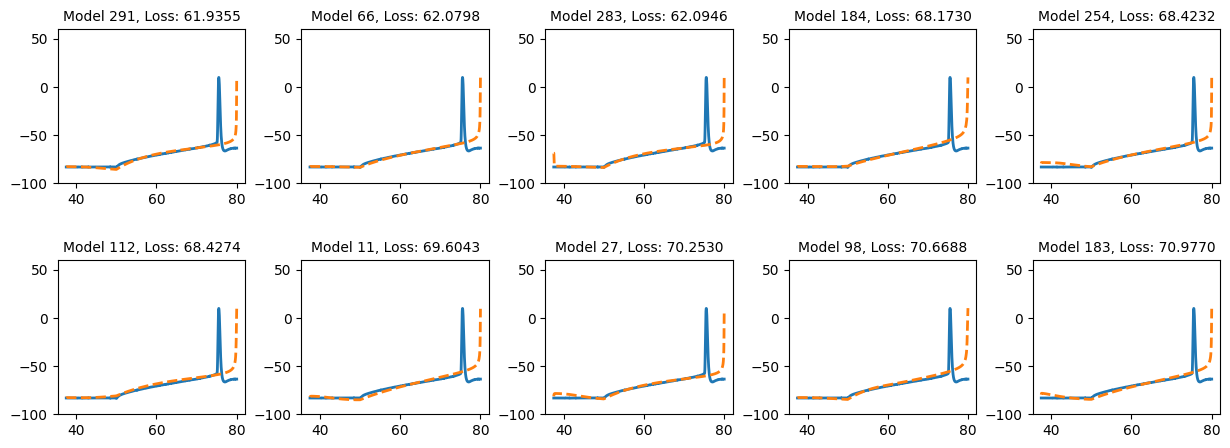

In [ ]:
# with spike reg
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'],  include_H=False, include_M=False, include_Ca=False, include_SKv=False)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        Na_dict = NaTs2T(gating_params=model.NaTs2T_gating_params).init_state(0, all_setup["v_init"], cell.channels[1].channel_params, dt)
        Na_m = Na_dict['NaTs2T_m']
        Na_h = Na_dict['NaTs2T_h']

        Sk_dict = SKE2(gating_params=model.SKE2_gating_params).init_state(0, all_setup['v_init'], cell.channels[2].channel_params, dt)
        Sk_z = Sk_dict['SKE2_z']

        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params, Na_m = Na_m, Na_h = Na_h, Sk_z = Sk_z, include_H=False, include_M=False, include_Ca=False, include_SKv=False)

        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

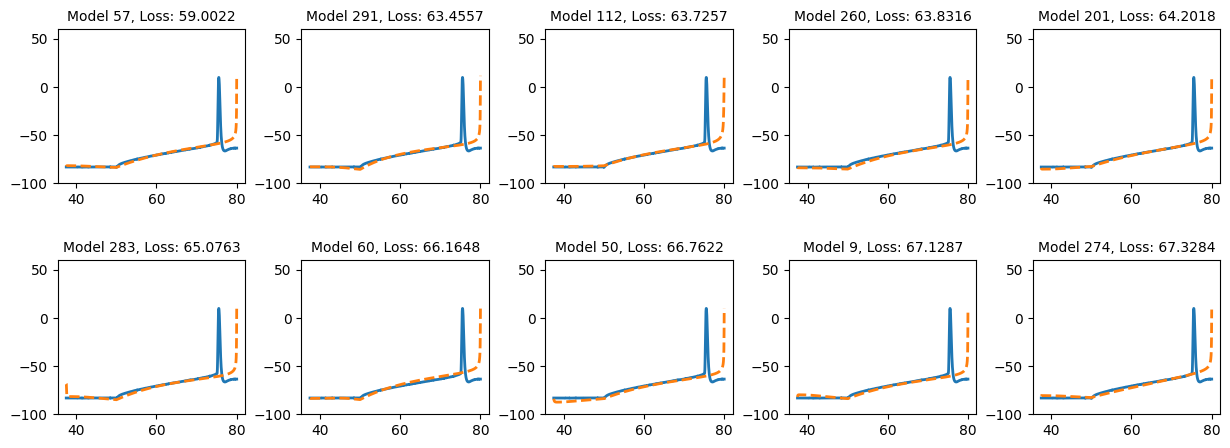

In [93]:
inds = np.argsort(best_gate_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[i*5+j]], best_gate_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'],  include_H=False, include_M=False, include_Ca=False, include_SKv=False)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        Na_dict = NaTs2T(gating_params=model.NaTs2T_gating_params).init_state(0, all_setup["v_init"], cell.channels[1].channel_params, dt)
        Na_m = Na_dict['NaTs2T_m']
        Na_h = Na_dict['NaTs2T_h']

        Sk_dict = SKE2(gating_params=model.SKE2_gating_params).init_state(0, all_setup['v_init'], cell.channels[2].channel_params, dt)
        Sk_z = Sk_dict['SKE2_z']

        # Rebuild the simulator with new cell
        initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params, Na_m = Na_m, Na_h = Na_h, Sk_z = Sk_z, include_H=False, include_M=False, include_Ca=False, include_SKv=False)

        # Run simulation
        final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
        model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

(-100.0, 60.0)

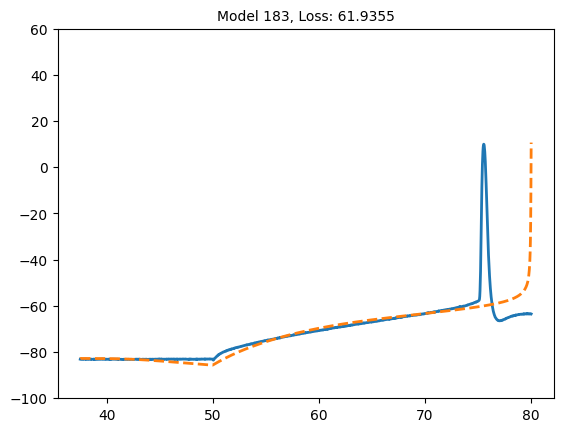

In [62]:
model = jax.tree_util.tree_map(lambda x: x[inds[0]], best_gate_models)
opt_inv_params = inv_transform_params(model.channel_params_normal)

# Rebuild the simulator with new cell
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'],  include_H=False, include_M=False, include_Ca=False, include_SKv=False)

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current, verbose = False)
cell.record(verbose = False)
cell.set("v", all_setup['v_init'])
cell.init_states()

Na_dict = NaTs2T(gating_params=model.NaTs2T_gating_params).init_state(0, all_setup["v_init"], cell.channels[1].channel_params, dt)
Na_m = Na_dict['NaTs2T_m']
Na_h = Na_dict['NaTs2T_h']

Sk_dict = SKE2(gating_params=model.SKE2_gating_params).init_state(0, all_setup['v_init'], cell.channels[2].channel_params, dt)
Sk_z = Sk_dict['SKE2_z']

# Rebuild the simulator with new cell
initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params, Na_m = Na_m, Na_h = Na_h, Sk_z = Sk_z, include_H=False, include_M=False, include_Ca=False, include_SKv=False)

# Run simulation
final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
)
plt.plot(time_vec, v_data[0], label="Multi-compartment target", linewidth=2)
plt.plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.title(f"Model {inds[i*5+j]}, Loss: {best_gate_losses[inds[0]]:.4f}", fontsize = 10)
plt.ylim(-100, 60)

Text(0.5, 1.0, 'Neural network output (neural_net)')

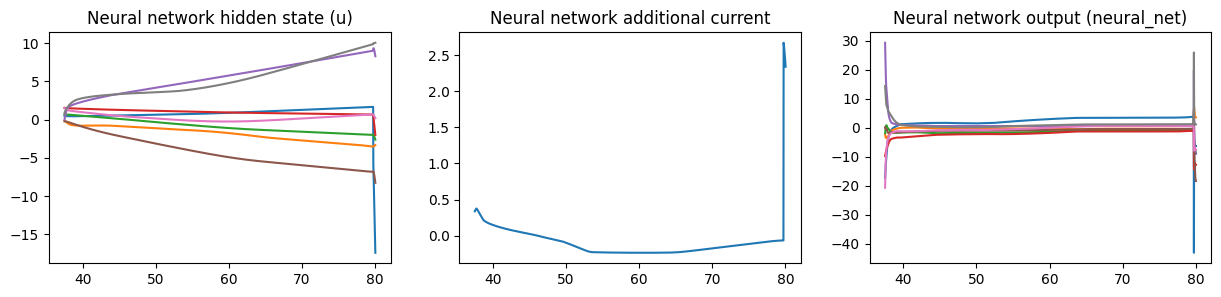

In [63]:
fig, axs = plt.subplots(1,3, figsize = (15,3))
axs[0].plot(time_vec, final_us)
axs[0].set_title("Neural network hidden state (u)")
axs[1].plot(time_vec, final_additional_currents)
axs[1].set_title("Neural network additional current")
axs[2].plot(time_vec, final_nn_reses)
axs[2].set_title("Neural network output (neural_net)")

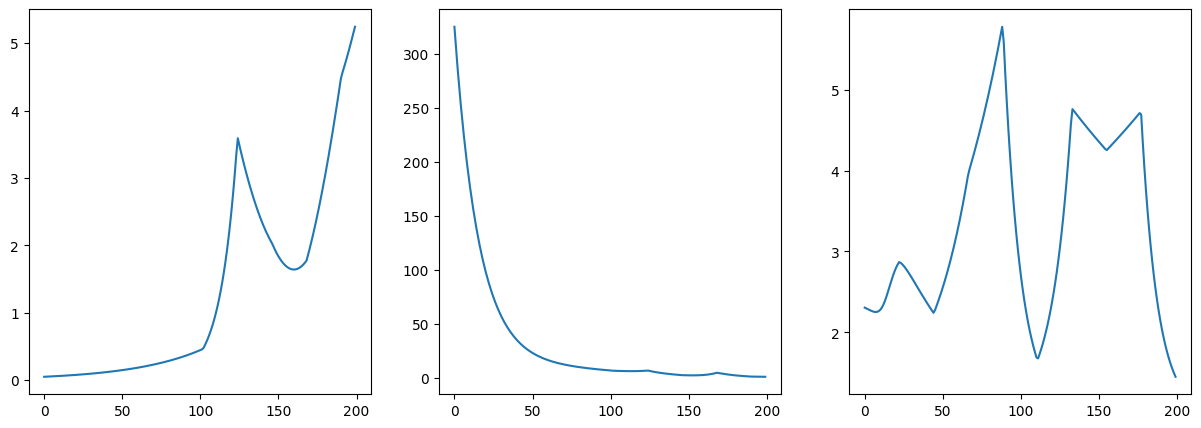

In [77]:
from jaxley.solver_gate import (
    save_exp
)
from jax.lax import select

def linear_interp(x, xp, fp):
    """Linear interpolation for JAX."""
    idx = jnp.clip(jnp.searchsorted(xp, x, side="right") - 1, 0, len(xp) - 2)
    x0 = xp[idx]
    x1 = xp[idx + 1]
    y0 = fp[idx]
    y1 = fp[idx + 1]
    slope = (y1 - y0) / (x1 - x0 + 1e-8)
    return y0 + slope * (x - x0)


def interpolate_params(v, x_vals, params):
    interp = linear_interp(v, x_vals, params)
    return jnp.exp(interp)

def m_gate(v, vt, x_vals = None, m_alpha_params = None, m_beta_params = None):
        """Voltage-dependent dynamics for the m gating variable."""
        modified = m_alpha_params != None
        if x_vals is None:
            x_vals = jnp.linspace(-100, 50, 10)

        qt = 2.3 ** ((34 - 21) / 10)
        v += vt
        alpha = (0.182 * (v + 32 + 1e-6)) / (1 - save_exp(-(v + 32 + 1e-6) / 6))
        beta = (0.124 * (-v - 32 + 1e-6)) / (1 - save_exp(-(-v - 32 + 1e-6) / 6))

        if(modified):
            alpha += interpolate_params(v, x_vals, m_alpha_params)
            beta += interpolate_params(v, x_vals, m_beta_params)

        # m_inf = alpha / (alpha + beta)
        # tau_m = 1 / (alpha + beta) / qt
        # return m_inf, tau_m
        return alpha, beta

def z_gate(cai, x_vals = None, z_gate_params = None):
        """Dynamics for the z gating variable, dependent on intracellular calcium concentration."""
        modified = z_gate_params != None
        if x_vals is None:
            x_vals = jnp.linspace(1e-7, 0.005, 10)


        cai = select(
            cai < jnp.asarray(1e-7),
            cai + 1e-7,
            cai,
        )
        z_inf = 1 / (1 + (0.00043 / cai) ** 4.8)
        tau_z = 1.0  # tau_z is fixed at 1 ms
        if(modified):
            z_inf += interpolate_params(cai, x_vals, z_gate_params)
            # logit_z = jnp.log(z_inf / (1 - z_inf))  # convert to logit space
            # logit_z += interpolate_params(cai, x_vals, z_gate_params)
            # z_inf = jax.nn.sigmoid(logit_z)   
        return z_inf, tau_z


voltages = np.linspace(-100, 50, 200)
am, bm = m_gate(voltages, -60, None, model.NaTs2T_gating_params[:10], model.NaTs2T_gating_params[10:20])
z_inf, _ = z_gate(jnp.linspace(1e-7, 0.005, 200), None, model.SKE2_gating_params)

fig, axs = plt.subplots(1,3, figsize = (15,5))
axs[0].plot(am)
axs[1].plot(bm)
axs[2].plot(z_inf)


In [44]:
model.NaTs2T_gating_params

Array([-1.26041831, -0.77486434,  1.27731297,  0.61875495, -0.22277972,
        0.38841638, -0.26946892,  2.00208288, -0.1710139 , -0.21250344,
        0.56800213, -0.86715984,  0.98174448, -1.16172045,  1.41193802,
        0.18343968,  0.01159283, -1.78227878, -1.72743795,  2.23471699,
        0.65426925,  0.77887554, -1.00008726,  0.74800534,  0.25148185,
       -0.01518515, -0.20985788,  0.18872486,  0.3118973 ,  0.2534858 ,
       -0.95413983, -0.55037525, -0.0048582 ,  1.35236981, -0.35533947,
       -0.89641494, -1.74983639, -0.74819542, -0.14590832,  0.36551118],      dtype=float64)

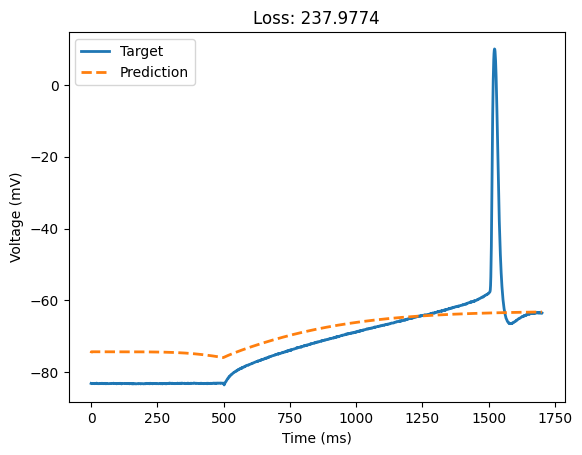

In [70]:
idx = 0
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], include_H=False, include_M=False, include_Ca=False)

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current, verbose = False)
cell.record(verbose = False)
cell.set("v", all_setup['v_init'])
cell.init_states()

model = jax.tree_util.tree_map(lambda x: x[1], models)
opt_inv_params = inv_transform_params(model.channel_params_normal)


Na_dict = NaTs2T(gating_params=model.NaTs2T_gating_params).init_state(0, all_setup["v_init"], cell.channels[1].channel_params, dt)
Na_m = Na_dict['NaTs2T_m']
Na_h = Na_dict['NaTs2T_h']

Na_m = 0.000291	#0.120032
Na_h = 0.979354 #0.573518

Sk_dict = SKv3_1(gating_params=model.SKv3_1_gating_params).init_state(0, all_setup['v_init'], cell.channels[2].channel_params, dt)
Sk_m = Sk_dict['SKv3_1_m']

#Sk_m = 0.000028

# Rebuild the simulator with new cell
initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params, Na_m = Na_m, Na_h = Na_h, Sk_m = Sk_m, include_H=False, include_M=False, include_Ca=False)

# Run simulation
final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
    model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
)

loss = simulation_loss_fn(model)


plt.plot(v_data[0], label="Data target", linewidth=2)
plt.plot(final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.title(f"Loss: {loss:.4f}")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend(["Target", "Prediction"])


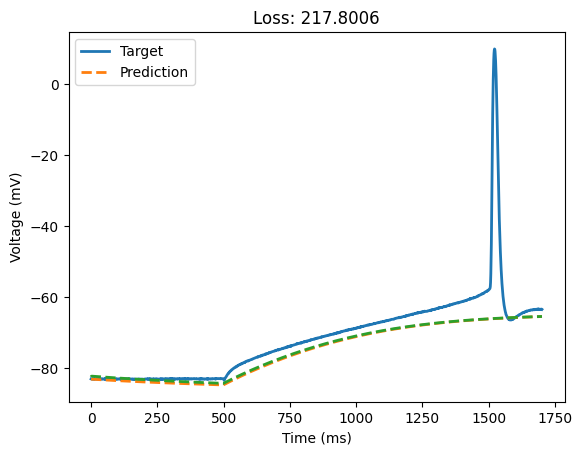

In [43]:
idx = 0
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], include_H=False, include_M=False, include_Ca=False)

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current, verbose = False)
cell.record(verbose = False)
cell.set("v", all_setup['v_init'])
cell.init_states()

model = jax.tree_util.tree_map(lambda x: x[1], models)
opt_inv_params = inv_transform_params(model.channel_params_normal)


Na_dict = NaTs2T(gating_params=model.Na_gating_params).init_state(0, all_setup["v_init"], cell.channels[1].channel_params, dt)
Na_m = Na_dict['NaTs2T_m']
Na_h = Na_dict['NaTs2T_h']

# Na_m = 0.120032
# Na_h = 0.573518

# Rebuild the simulator with new cell
initial_state, step_fn, current, time_vec = setup_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params, Na_m = Na_m, Na_h = Na_h, include_H=False, include_M=False, include_Ca=False)

# Run simulation
new_final_preds, final_additional_currents, final_us, final_nn_reses = simulate_full_trace(
    model.spike_neural_net, model.spike_readout_net, model.nospike_neural_net, model.nospike_readout_net, initial_state, step_fn, current, time_vec, u_init, v_data.squeeze(), added_curr_std, nospike_u_time_constant, spike_u_time_constant, thr
)

loss = simulation_loss_fn(model)


plt.plot(v_data[0], label="Data target", linewidth=2)
plt.plot(final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.plot(new_final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
plt.title(f"Loss: {loss:.4f}")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.legend(["Target", "Prediction"])

In [38]:
Na_h

Array(0.65619135, dtype=float64)

In [128]:
cell = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], include_H=False, include_M=False, include_Ca=False)

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current, verbose = False)
cell.record(verbose = False)
cell.set("v", all_setup['v_init'])
cell.init_states()

In [129]:
cell.channels

In [120]:
from voltage_fitting.channels import NaTs2T

cell2 = build_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], include_H=False, include_M=False, include_Ca=False)

cell2.delete_stimuli()
cell2.delete_recordings()

cell2.stimulate(current, verbose = False)
cell2.record(verbose = False)
cell2.set("v", all_setup['v_init'])
cell2.init_states()

cell2.insert(NaTs2T(gating_params=jnp.ones(40)*2))

In [91]:
cell.nodes

,local_cell_index,local_branch_index,local_comp_index,length,radius,axial_resistivity,capacitance,v,global_cell_index,global_branch_index,...,NaTs2T_m,NaTs2T_h,SKv3_1,SKv3_1_gSKv3_1,eK,SKv3_1_m,SKE2,SKE2_gSKE2,SKE2_z,CaCon_i
0,0,0,0,197.0,8.0,100.0,1.0,-83.15625,0,0,...,0.120032,0.573518,True,0.00001,-77.0,0.000028,True,0.000001,0.000033,0.00005


In [107]:
cell2.nodes

,local_cell_index,local_branch_index,local_comp_index,length,radius,axial_resistivity,capacitance,v,global_cell_index,global_branch_index,...,SKE2,SKE2_gSKE2,SKE2_z,CaCon_i,NaTs2T,NaTs2T_gNaTs2T,eNa,vt,NaTs2T_m,NaTs2T_h
0,0,0,0,197.0,8.0,100.0,1.0,-83.15625,0,0,...,True,0.000001,0.000033,0.00005,True,0.00001,50.0,0.0,0.1,0.1


In [113]:
cell2.channels[3].gating_params

{'m_alpha_params': Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float64),
 'm_beta_params': Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float64),
 'h_alpha_params': Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float64),
 'h_beta_params': Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float64)}

In [121]:
cell2.init_states()
cell2.nodes

,local_cell_index,local_branch_index,local_comp_index,length,radius,axial_resistivity,capacitance,v,global_cell_index,global_branch_index,...,SKE2,SKE2_gSKE2,SKE2_z,CaCon_i,NaTs2T,NaTs2T_gNaTs2T,eNa,vt,NaTs2T_m,NaTs2T_h
0,0,0,0,197.0,8.0,100.0,1.0,-83.15625,0,0,...,True,0.000001,0.000033,0.00005,True,0.00001,50.0,0.0,0.50157,0.884877


In [ ]:
cell2.data_set()

In [131]:
dict = NaTs2T(gating_params=jnp.ones(40)*2).init_state(0, -83.15625, cell2.channels[3].channel_params, 0.025)
dict

{'NaTs2T_m': Array(0.50156999, dtype=float64),
 'NaTs2T_h': Array(0.88487731, dtype=float64)}

In [135]:
dict['NaTs2T_h'].item()

0.8848773108458032